# Intro

In this notebook, we will investigate what learning the generative model of the task could look like. In particular, we will frame learning as inference over possible schedules given observations. First, we will establish theoretical upper bounds on the inference problem from a statistical estimation point of view. Then, we will construct Bayes-optimal posteriors, which can serve as a ground truth when assessing sufficient statistics uncovered by agents trained on the task.

In [1]:
%matplotlib inline

#TODO: majorly refactor this notebook to reflect new modules
import os
import logging
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import polygamma
from itertools import permutations

from foraging import SEED
from foraging.utils.autoreload import setup_auto_reload

# Supress annoying warnings and filter out logs that aren't useful here
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# Set up development tools
setup_auto_reload()
pd.options.mode.copy_on_write = True

# from foraging.plotting import bp, format_yticks, per_block, titler
# from foraging.plotting.belief import (
#     plot_accuracy_across_block,
#     plot_cramer_rao_lb,
#     plot_fisher_info,
#     plot_schedule_beliefs_in_block,
#     plot_schedule_beliefs_mean_and_std_across_block,
# )
from foraging.models._base import HashableDict
from foraging.config.experiments import AngelakiPlottingConfig
from foraging.plotting.belief import BeliefPlotter, plot_fisher_info
from foraging.utils.belief import compute_accuracy, compute_posterior
from foraging.utils.data import (
    display_df,
    angelaki_exclusion_criteria,
    filter_df,
    make_angelaki_experiment,
    map_box_positions_to_ranks,
)
from foraging.models.distribution import (
    ExactBayesianUpdateOnProbabilities,
    FactorizedPosterior,
    RewardOutcomeLikelihood,
    RewardIntervalLikelihood,
    Permutation,
    PermutationLikelihood,
    GammaParameters,
    PossibleSchedules,
    Posterior,
    Probabilities,
)
pd.options.mode.copy_on_write = True

# constants
RNG = np.random.default_rng(SEED)
EXPERIMENT_DIR = "../../data/experiments/angelaki"
ANALYSIS_DIR = "../../data/analysis"

✅ Auto-reload extension loaded!
✅ Auto-reload w/ 2 mode enabled! Changes to all packages will be automatically loaded.


# Load data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Angelaki Data Cleaning` notebook.

In [2]:
%%capture --no-display
dataset = make_angelaki_experiment(EXPERIMENT_DIR)
dataset = angelaki_exclusion_criteria(dataset, EXPERIMENT_DIR)
dataset = dataset.filter(conds = {"shape": 1})
df = dataset.df
display_df(df, ["subject", "session", "block", "box", "push times", "reward outcomes"])

| subject | session | block | box | push times | reward outcomes |
| --- | --- | --- | --- | --- | --- |
| dylan | 20211206 | 2 | slow | 3.1349999997764826 | False |
| dylan | 20211206 | 2 | fast | 8.464999999850988 | False |
| dylan | 20211206 | 2 | fast | 9.467999999877065 | False |
| dylan | 20211206 | 2 | fast | 11.666999999899417 | False |
| dylan | 20211206 | 2 | medium | 17.125 | False |

Optimal Fisher info for schedule 5 with shape = 1 occurs at t = 7.9681, with value 0.0259
Optimal Fisher info for schedule 21 with shape = 1 occurs at t = 33.4661, with value 0.0015
Optimal Fisher info for schedule 35 with shape = 1 occurs at t = 55.7768, with value 0.0005


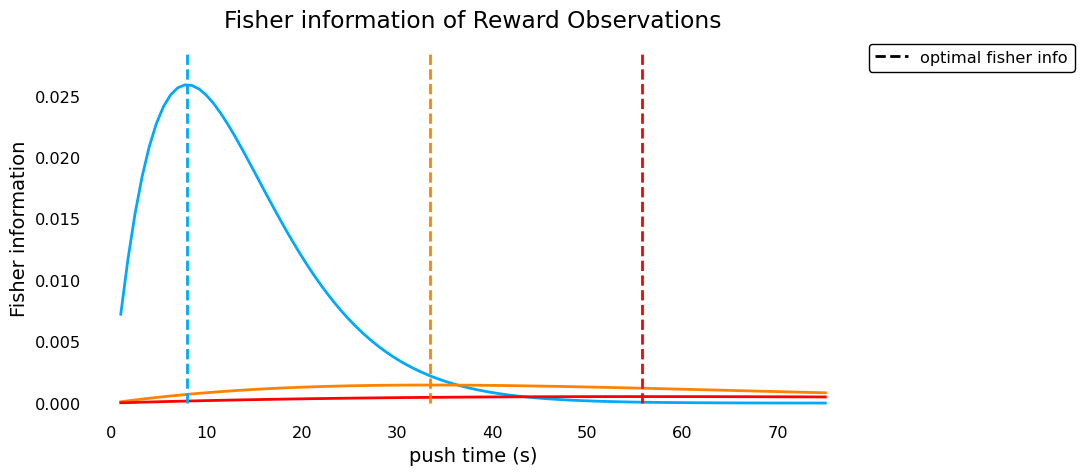

In [3]:
plot_fisher_info(
    np.linspace(1, 75, 100),
    schedules=[5, 21, 35],
    alpha=1,
    title="Fisher information of Reward Observations",
    palette = AngelakiPlottingConfig().PALETTE
);

## Empirical Beliefs using Censored Observations

Given real behavioral data, we can construct Bayes-optimal beliefs about the schedules using censored observations when the color cue is completely unreliable. These beliefs take the form of a posterior over possible schedules, and they are updated according to Bayes rule:

$$b(\lambda|o_n := t_{\text{push}}) \propto \begin{cases} F(t_{\text{push}} | \lambda)b(\lambda|o_{1:n-1}) & \text{if reward}\\ (1-F(t_{\text{push}} | \lambda))b(\lambda|o_{1:n-1}) &  \text{else}\end{cases}$$

Assuming a uniform prior over possible schedules that resets between blocks, the maximum a posteriori (MAP) estimator is equivalent to the maximum likelihood estimator (MLE). An example posterior over one block is shown below. Inferring the actual prior is an inverse problem that we leave for downstream analysis.

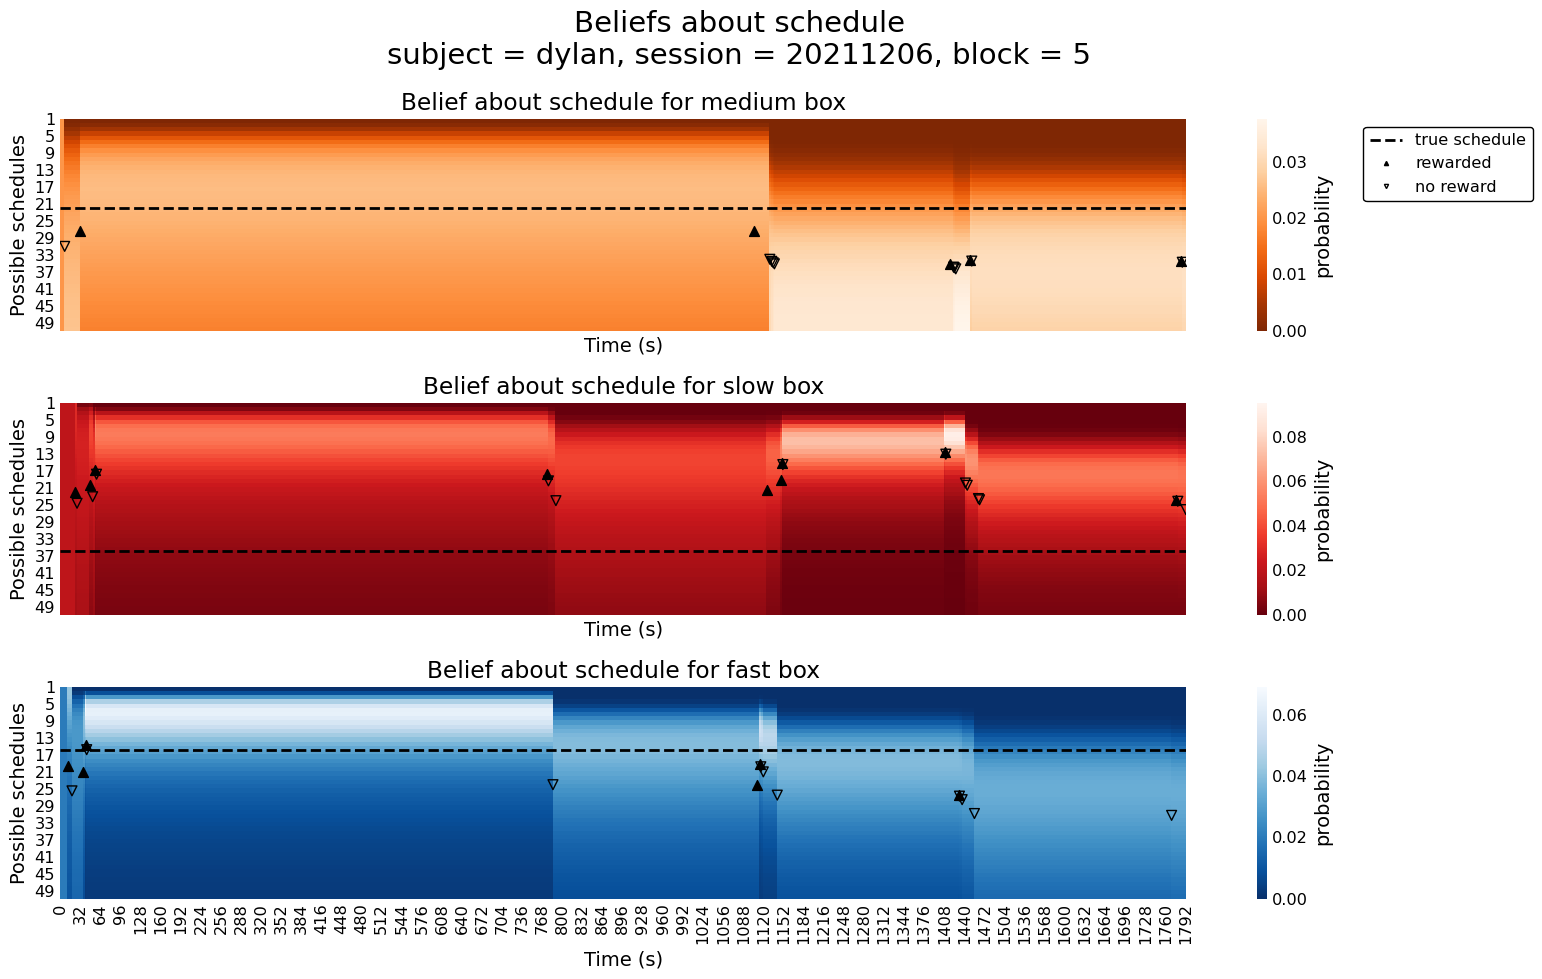

In [4]:
schedule_candidates = np.arange(50) + 1
belief_update = ExactBayesianUpdateOnProbabilities(RewardOutcomeLikelihood(), vectorize=True)

def posterior_maker(dataset, block_key, block) -> FactorizedPosterior:
    shape = block.index.unique("shape")[0]
    n_boxes = block["n boxes"].values[0]
    uniform = 1 / len(schedule_candidates) * np.ones(len(schedule_candidates))
    single_box_prior = Probabilities(
        support=PossibleSchedules(schedule=schedule_candidates, shape=shape),
        probabilities=uniform,
    )
    return FactorizedPosterior(
        n_boxes, block_key.update("push time", 0), belief_update, prior=single_box_prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_posterior, posterior_maker = posterior_maker)
plotter = BeliefPlotter(schedule_beliefs, dataset, AngelakiPlottingConfig().to_dict())
plotter.plot_schedule_beliefs_in_block(conds = dict(subject="dylan", session=20211206, block=5));

In [4]:
test = HashableDict({"a": 1, "b": 2})
test.update("c", 3)

{'a': 1, 'b': 2, 'c': 3}

Now we will aggregate posteriors over blocks and report the average summary statistics of those posteriors.

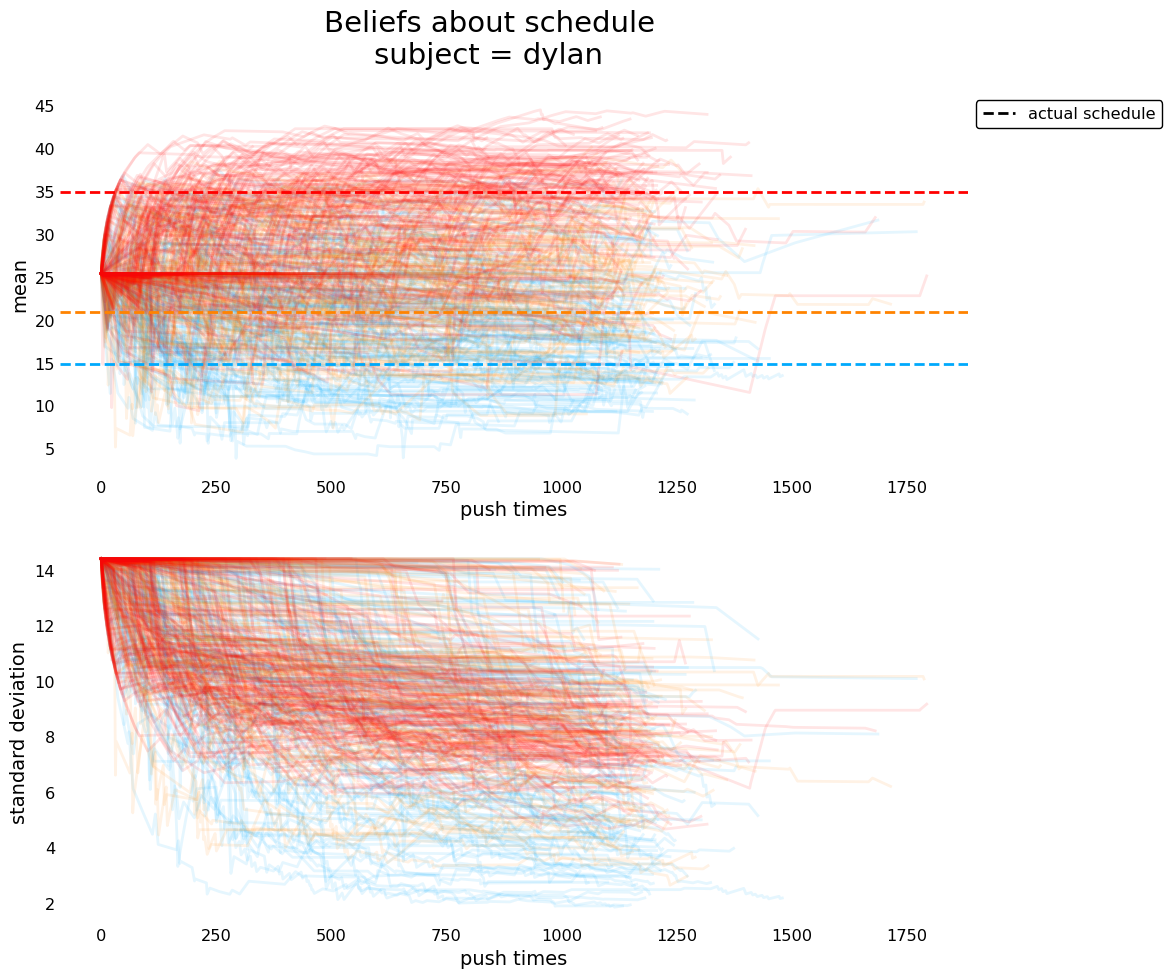

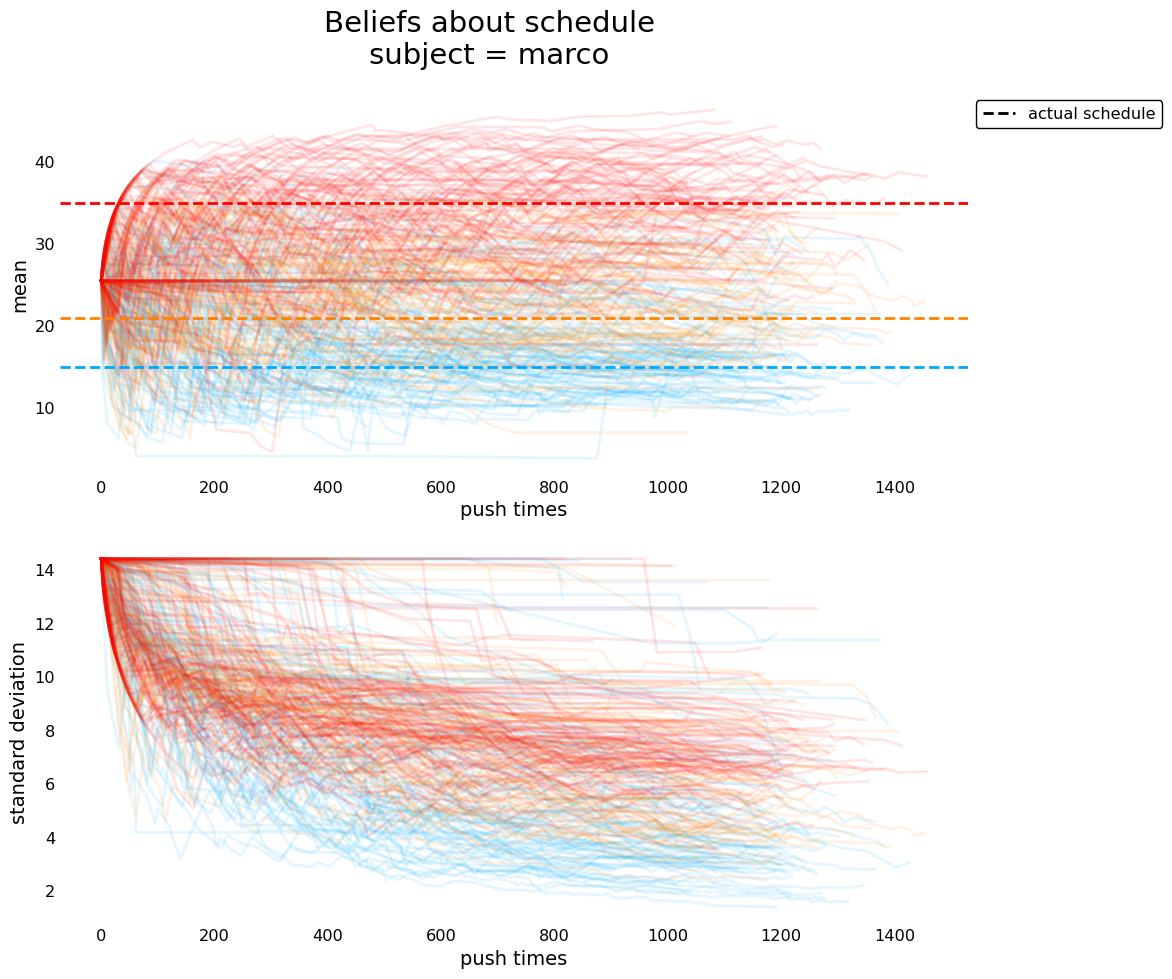

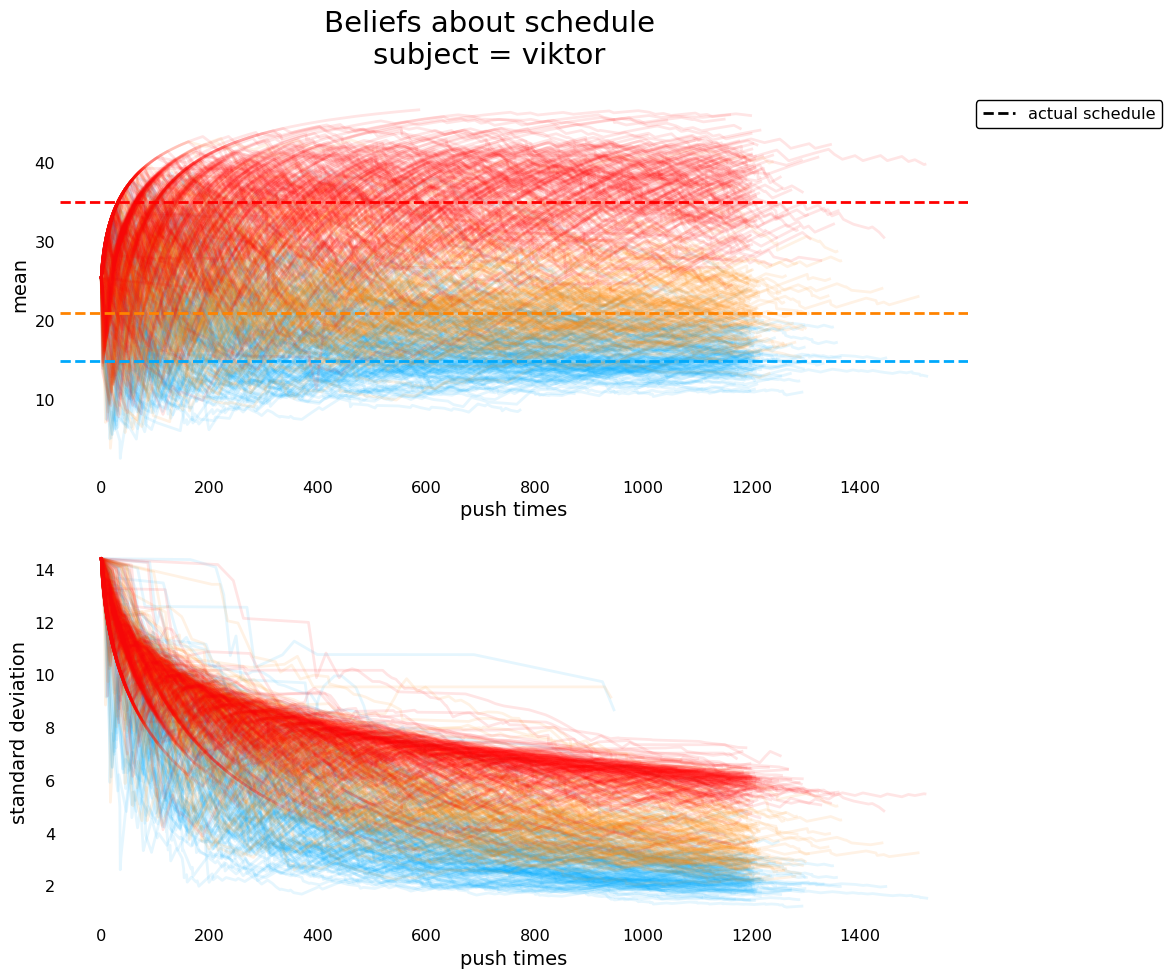

In [32]:
plotter.plot_schedule_beliefs_mean_and_std_across_block(
    x="push times",
    show_traces=True,
    show_average = False
);

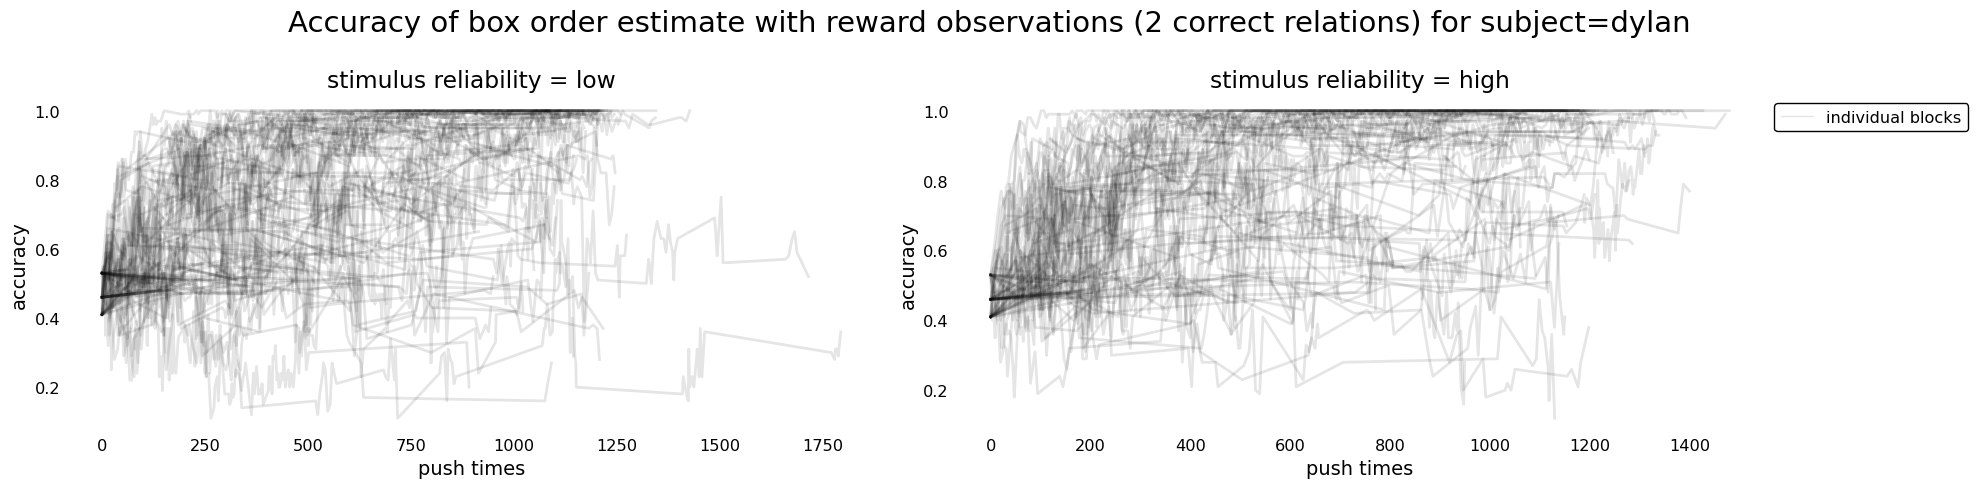

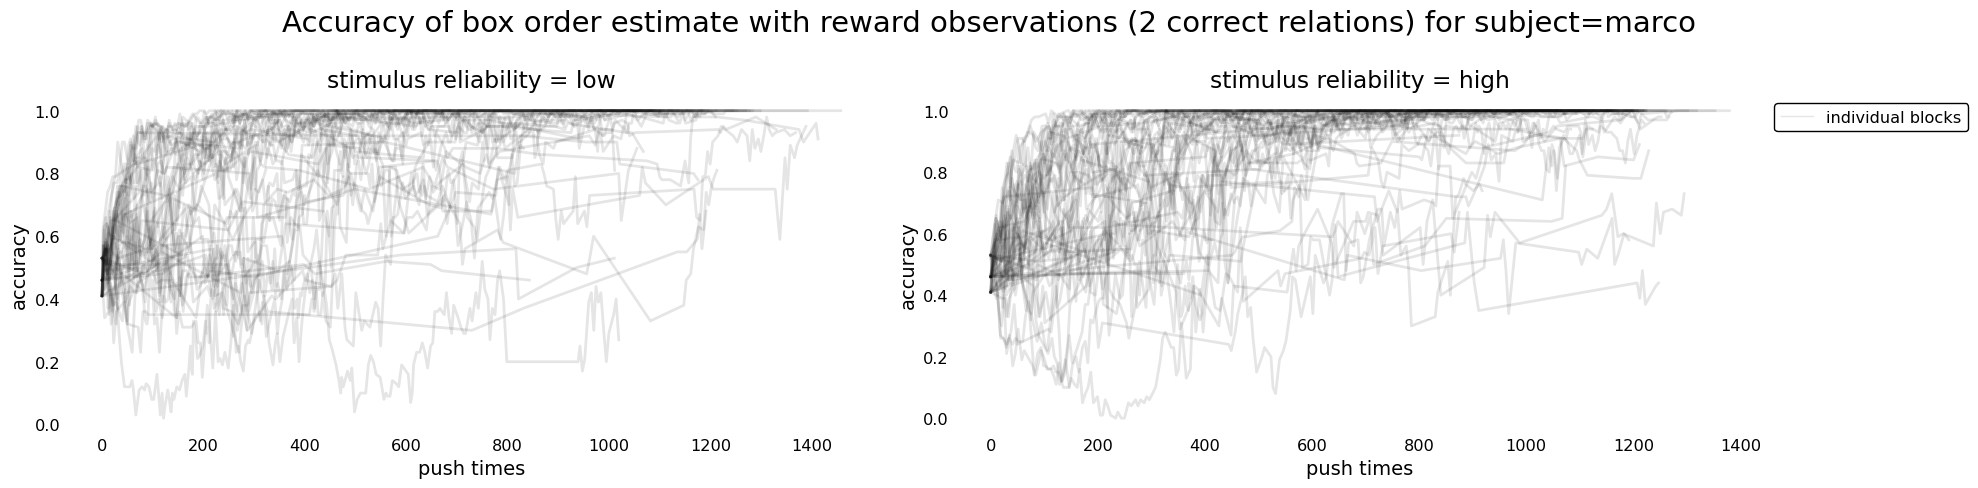

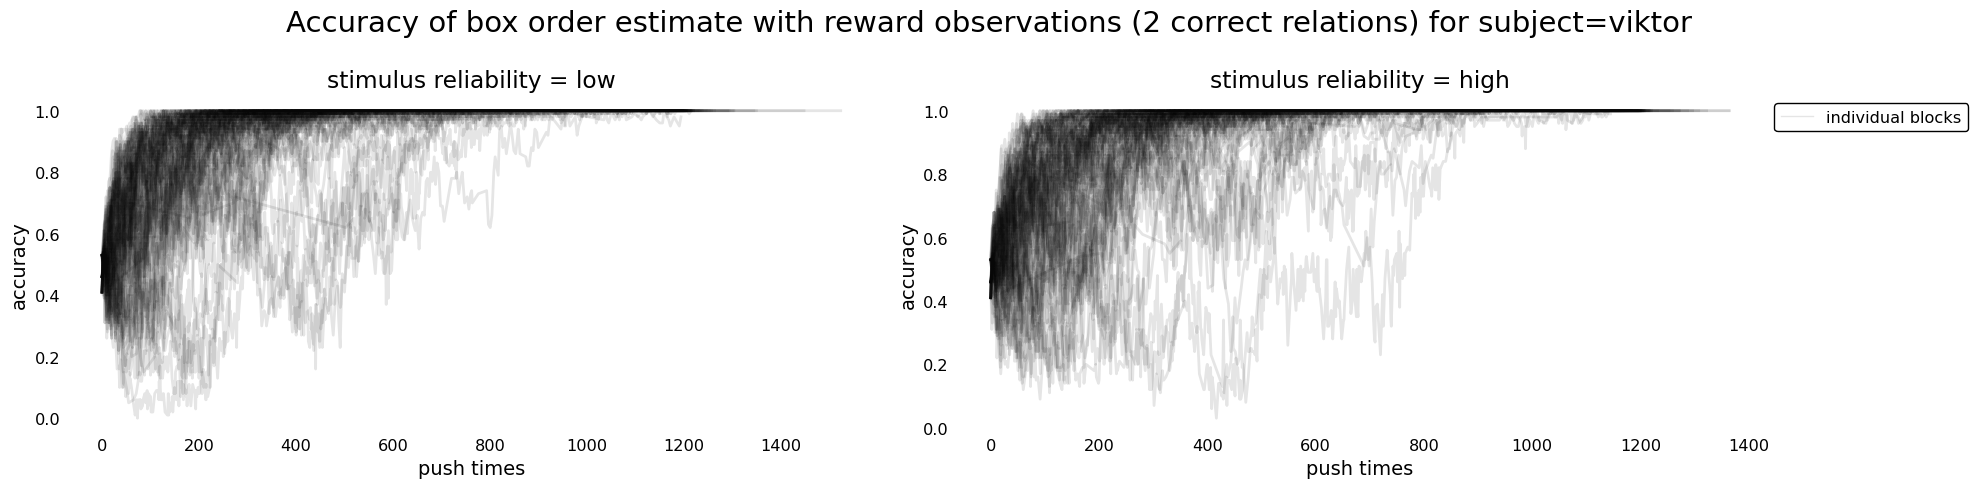

In [26]:
n_correct = 2
accuracies, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = n_correct, n_samples = 100)
plotter.plot_conditions_by_subject(
    plotter.plot_accuracy_across_block, 
    accuracies = accuracies,
    col_condition = 'stimulus reliability',
    x="push times",
    show_traces=True,
    show_average = False,
    color="black",       
    fig_title=f'Accuracy of box order estimate with reward observations ({n_correct} correct relations)' 
);

For getting the order of all the boxes right there is quite a lot of variance among blocks, but as we relax this requirement and vary how many order relations the subjects need to get right, we see the accuracy actually goes up near the end of the block!

In [7]:
#TODO: illustrate blocks where the accuracy is low for n_correct = 3 but high for n_correct < 3
accuracies_3, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 3, n_samples = 500)
accuracies_2, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 2, n_samples = 500)
accuracies_1, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = 1, n_samples = 500)

In [9]:
import numpy as np

# accuracies: dict[HashableDict (or tuple), ArrayLike]
worst_key, worst_max = [None]*15, np.array([np.inf]*15)

for key, acc in accuracies_3.items():
    if key['subject'] != 'viktor':
        continue

    stim_reliability = dataset.filter(key).get_unique("stimulus reliability")[0]
    if stim_reliability != "high":
        continue

    acc = np.asarray(acc, dtype=float)
    # m = np.nanmax(acc)  # use max(acc) if you know there are no NaNs
    m = acc[-1]
    w = np.argmax(worst_max)
    if m < worst_max[w]:
        worst_max[w] = m
        worst_key[w] = key

print("block with lowest max accuracy:", worst_key)
print("that block's max accuracy:", worst_max)

block with lowest max accuracy: [{'subject': 'viktor', 'session': np.int64(20221018), 'block': np.int64(1)}, {'subject': 'viktor', 'session': np.int64(20221019), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20221021), 'block': np.int64(7)}, {'subject': 'viktor', 'session': np.int64(20221021), 'block': np.int64(8)}, {'subject': 'viktor', 'session': np.int64(20221025), 'block': np.int64(5)}, {'subject': 'viktor', 'session': np.int64(20221026), 'block': np.int64(4)}, {'subject': 'viktor', 'session': np.int64(20221101), 'block': np.int64(2)}, {'subject': 'viktor', 'session': np.int64(20221101), 'block': np.int64(6)}, {'subject': 'viktor', 'session': np.int64(20221108), 'block': np.int64(1)}, {'subject': 'viktor', 'session': np.int64(20221013), 'block': np.int64(1)}, {'subject': 'viktor', 'session': np.int64(20221013), 'block': np.int64(3)}, {'subject': 'viktor', 'session': np.int64(20221117), 'block': np.int64(5)}, {'subject': 'viktor', 'session': np.int64(20230110), 'b

{'subject': 'viktor', 'session': np.int64(20221018), 'block': np.int64(1)}


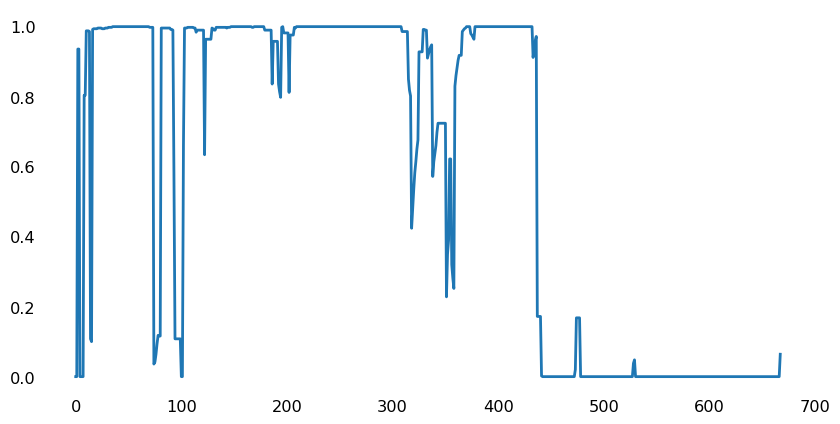

In [10]:
plt.plot(accuracies_3[worst_key[0]])
print(worst_key[0])

{'subject': 'viktor', 'session': np.int64(20221018), 'block': np.int64(1)}


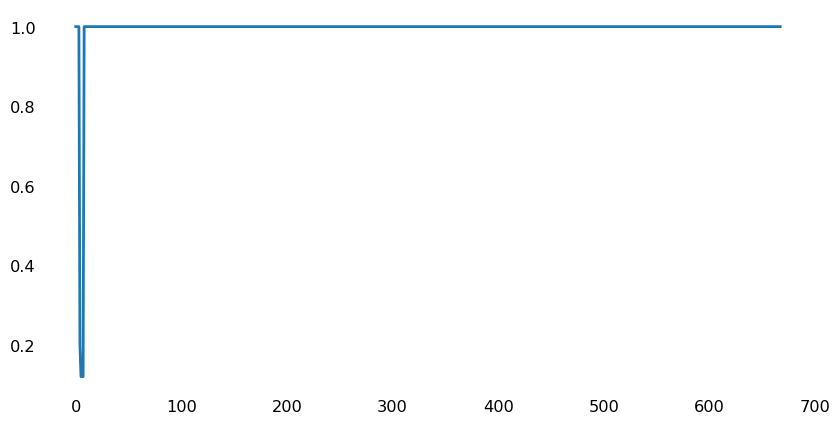

In [11]:
plt.plot(accuracies_2[worst_key[0]])
print(worst_key[0])

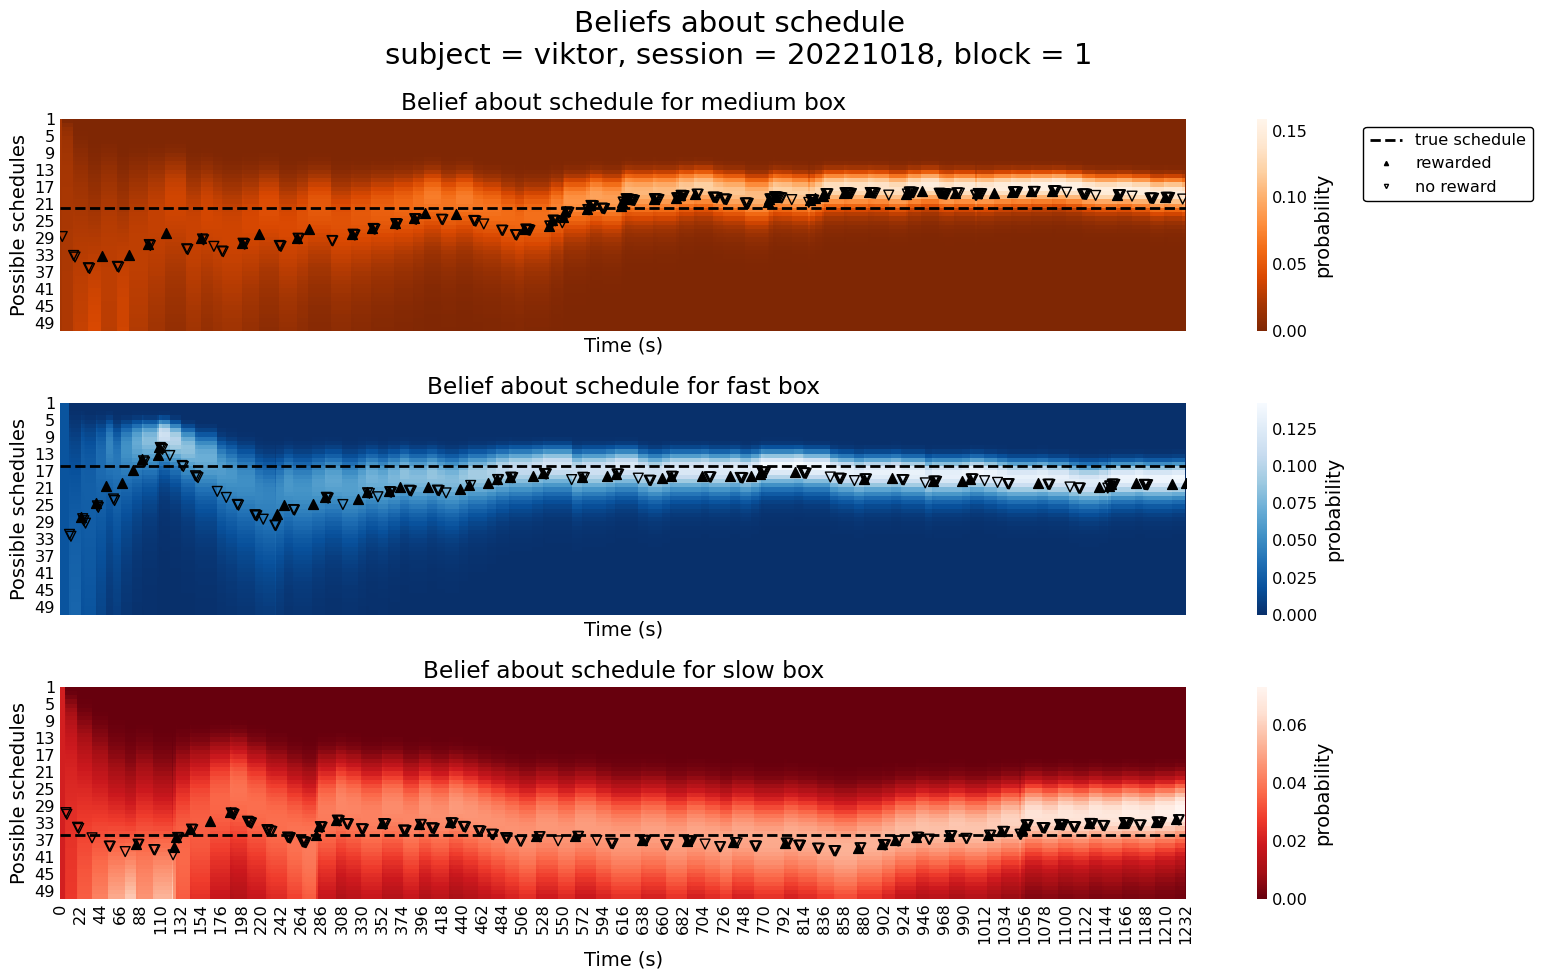

In [71]:
plotter.plot_schedule_beliefs_in_block(conds = dict(subject="viktor", session=20221018, block=1));

In [62]:
_df = dataset.df
np.unique(_df.index.get_level_values(_df.index.names.index("assigned schedules"))[0]).size

3

In [14]:
import pandas as pd

df_acc = pd.DataFrame(
    [{**dict(k), "accuracy": v} for k, v in accuracies_3.items()]
)
df_acc

,subject,session,block,accuracy
0,dylan,20211206,2,"[1.0, 1.0, 0.03, 0.03, 0.03, 0.05, 0.05, 0.02,..."
1,dylan,20211206,3,"[0.0, 0.0, 0.0, 0.91, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,dylan,20211206,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,dylan,20211206,5,"[0.0, 0.0, 0.03, 0.01, 0.0, 0.0, 0.0, 0.01, 0...."
4,dylan,20211206,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...
447,viktor,20230217,3,"[1.0, 1.0, 0.03, 0.34, 0.34, 0.34, 0.03, 0.0, ..."
448,viktor,20230217,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
449,viktor,20230217,5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.07, 0.0,..."
450,viktor,20230217,6,"[0.0, 0.0, 0.94, 0.89, 0.89, 0.89, 0.82, 0.82,..."


In [ ]:
import numpy as np
import pandas as pd

rows = []
accuracies = accuracies_3
for key, acc in accuracies.items():
    key_dict = dict(key) if not isinstance(key, tuple) else None
    acc = np.asarray(acc)

    for t, a in enumerate(acc):
        rows.append({
            **(key_dict if key_dict is not None else {"key": key}),
            "t": t,
            "accuracy": float(a),
        })

df_acc = pd.DataFrame(rows)
df_acc[]

,subject,session,block,t,accuracy
0,dylan,20211206,2,0,1.00
1,dylan,20211206,2,1,1.00
2,dylan,20211206,2,2,0.03
3,dylan,20211206,2,3,0.03
4,dylan,20211206,2,4,0.03
...,...,...,...,...,...
119630,viktor,20230217,7,179,1.00
119631,viktor,20230217,7,180,1.00
119632,viktor,20230217,7,181,1.00
119633,viktor,20230217,7,182,1.00


## What if the subjects know the identities of the schedules just not their ordering?

Now, this framework is only applicable if we assume the subjects 1) treat the boxes as independent and 2) start their inference process from scratch at the start of each block. If the schedules are kept constant over several blocks and merely permuted, then it is conceivable that the subjects eventually get a good handle on the identities of the schedules and only infer the assighment of specific schedules to boxes, not the values of the schedules themselves. In that case, their beliefs are defined over $m!$ permutations, where $m$ is the number of boxes. Analogous to the Fisher information, one can simulate observations under one of the permutations and show how quickly the posterior converges to the right permutation as a function of the number of observations (the result will generalize to the other permutations).

With respect to box ordering, the permutation and continuous beliefs from before carry the same amount of information (in fact, the continuous beliefs can converge to the permutation beliefs via Monte Carlo). Obviously, when it comes the values of the schedules themselves, the permutations don't carry that information since this knowledge is assumed, and that the only knowledge missing is the assignment of schedules to box positions.

<Axes: >

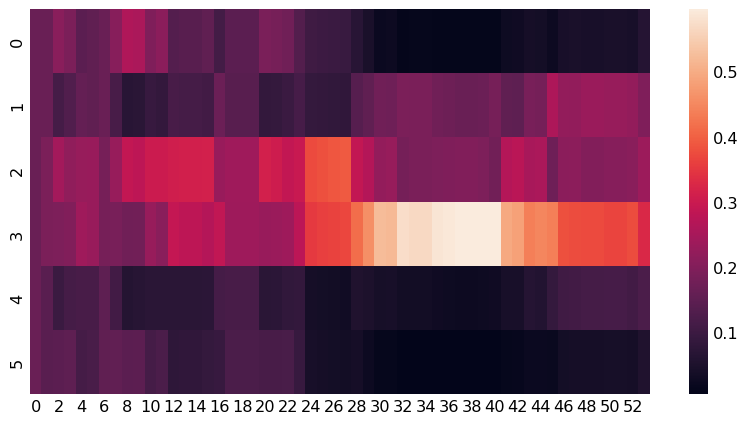

In [ ]:
from foraging.models.distribution import Permutation2SchedulesWrapper

_belief_update = ExactBayesianUpdateOnProbabilities(PermutationLikelihood())
def belief_update(x, y):
    p = _belief_update(x, y)
    return Permutation2SchedulesWrapper(p.support, p.representation)

def posterior_maker(dataset, block_key, block) -> Posterior:
    block = block.reset_index()
    shape = block["shape"].iloc[0]
    schedules = sorted(block["assigned schedules"].iloc[0])
    perms = list(permutations(schedules))
    uniform = 1 / len(perms) * np.ones(len(perms))
    prior = Permutation2SchedulesWrapper(
        support= [Permutation(permutation = x, shape = shape) for x in perms],
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return Posterior(
        new_key, update = belief_update, prior=prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_posterior, posterior_maker = posterior_maker)
probs = np.asarray(schedule_beliefs[HashableDict(subject="dylan", session=20211206, block=5)].representation)
sns.heatmap(probs.T)

In [15]:
list(schedule_beliefs.values())[0].head

Count how many correct order relations for each box

In [27]:
from foraging.utils.belief import compute_per_box_accuracy
accuracies, _ = dataset.process_blocks(compute_per_box_accuracy, beliefs = schedule_beliefs, n_correct = 3, n_samples = 500)

In [109]:
accuracies

{{'subject': 'dylan',
  'session': np.int64(20211206),
  'block': np.int64(2)}: {'correct_counts': array([[[0.   , 1.   , 1.   ],
          [0.   , 0.   , 1.   ],
          [0.   , 0.   , 0.   ]],
  
         [[0.   , 1.   , 1.   ],
          [0.   , 0.   , 1.   ],
          [0.   , 0.   , 0.   ]],
  
         [[0.   , 0.026, 0.068],
          [0.974, 0.   , 1.   ],
          [0.932, 0.   , 0.   ]],
  
         ...,
  
         [[0.   , 1.   , 1.   ],
          [0.   , 0.   , 0.994],
          [0.   , 0.006, 0.   ]],
  
         [[0.   , 1.   , 1.   ],
          [0.   , 0.   , 0.994],
          [0.   , 0.006, 0.   ]],
  
         [[0.   , 1.   , 1.   ],
          [0.   , 0.   , 0.994],
          [0.   , 0.006, 0.   ]]], shape=(202, 3, 3)), 'time': array([   0.   ,    3.135,    8.465,    9.468,   11.667,   17.125,
           19.904,   25.48 ,   27.745,   32.435,   37.34 ,   38.525,
           43.237,   45.337,   46.305,   48.105,   49.53 ,   51.736,
           53.296,   57.385,   58.381

In [28]:
t_cut = 700
vals = defaultdict(list)
for k, v in accuracies.items():
    time = v["time"]
    if time[-1] < t_cut:
        continue   
    vals[k["subject"]].append(v["correct_counts"][time > t_cut])

vals_viktor = np.vstack(vals["viktor"])
vals_marco = np.vstack(vals["marco"])
vals_dylan = np.vstack(vals["dylan"])

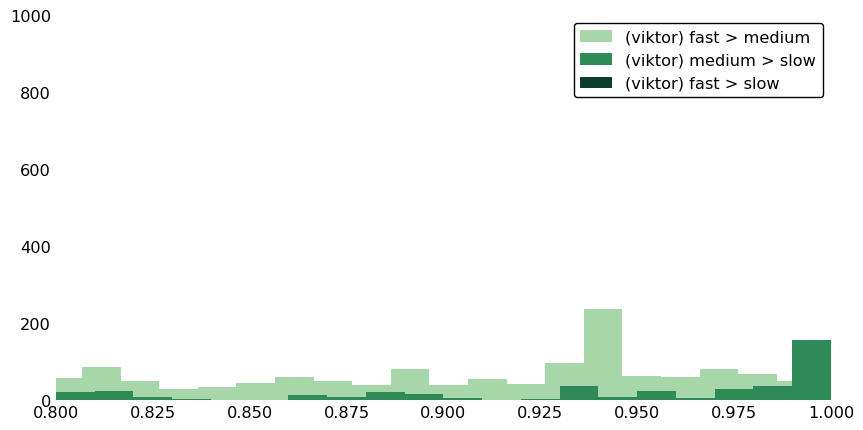

In [33]:
plt.hist(vals_viktor[:,1,0], label = "(viktor) fast > medium", bins = 100, color = '#A7D7A9')
plt.hist(vals_viktor[:,2,1], label = "(viktor) medium > slow", bins = 100, color = '#2E8B57')
plt.hist(vals_viktor[:,2,0], label = "(viktor) fast > slow", bins = 100, color = '#0B3D2E')

# plt.hist(vals_marco[:,1,0], label = "(marco) fast > medium", bins = 100, color = '#F5CBA7')
# plt.hist(vals_marco[:,2,1], label = "(marco) medium > slow", bins = 100, color = '#E67E22')
# plt.hist(vals_marco[:,2,0], label = "(marco) fast > slow", bins = 100, color = '#7A2E00')

# plt.hist(vals_dylan[:,1,0], label = "(dylan) fast > medium", bins = 100, color = '#0B1F3B')
# plt.hist(vals_dylan[:,2,1], label = "(dylan) medium > slow", bins = 100, color = '#1F77B4')
# plt.hist(vals_dylan[:,2,0], label = "(dylan) fast > slow", bins = 100, color = '#A9CCE3')

# plt.hist(vals_all[:,1,2]/500, label = "medium > slow")
plt.xlim(0.8, 1)
plt.ylim(0, 1000)
plt.legend()